# Route flow graphs

`sameer_graph_lib` can turn a table of route rows into a directed
`pickup_cluster -> drop_cluster` graph where every edge carries a metric cube
over the grain dimensions (`week_period` x `hour` here).

This notebook covers the whole route stack:

1. build the graph from a DataFrame, naming your own columns
2. ask where a cluster's orders come from and where they go
3. plot that flow, several variables at a time, as tables on the nodes and
   edges, gathering everything outside the top x into a rest node
4. filter on edge or node metrics, into a new graph or by pruning in place
5. reachability: what can get here within a time budget, and by which route
6. the supporting views: partners, profiles, matrix, whole graph
7. the stateless DataFrame plotter (multi-column, multi-axis, multi-group, distributions)
8. a graph from a single H3 column, when the data has no routes in it at all

Install what it needs with `pip install -e ".[analysis]"`.

In [1]:
import sys, os
# Make the in-tree package importable without pip install -e .
_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir, 'src'))
if _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

import numpy as np
import pandas as pd

from sameer_graph_lib import RouteExplorer, plotter

pd.set_option('display.width', 110)
pd.set_option('display.max_columns', 20)

## 1. The input

One row per `pickup_cluster x drop_cluster x week_period x hour`, plus whatever
metric columns you export. The demo frame is synthetic: `A1` collects from
`C1..C6`, feeds `B1..B6`, and `C1`/`C2` are themselves fed by `D1..D6`, so the
graph has something to show two levels out in either direction.

Column names are yours - nothing in the library is hardcoded to these.

In [2]:
def make_demo_frame(seed=11):
    rng = np.random.default_rng(seed)
    edges = (
        [('A1', f'B{i}') for i in range(1, 7)]
        + [(f'C{i}', 'A1') for i in range(1, 7)]
        + [(f'D{i}', 'C1') for i in range(1, 5)]
        + [(f'D{i}', 'C2') for i in range(3, 7)]
        + [('A1', 'A2'), ('A2', 'A1'), ('B1', 'C1')]
    )
    rows = []
    for pickup, drop in edges:
        pull = rng.uniform(0.4, 2.0)
        for week_period in ('weekday', 'weekend'):
            for hour in range(24):
                if rng.random() < 0.25:          # not every bucket has data
                    continue
                peak = 1.8 if hour in (8, 9, 10, 18, 19, 20) else 1.0
                requests = float(rng.integers(20, 400) * pull * peak)
                rows.append({
                    'pickup_cluster': pickup,
                    'drop_cluster': drop,
                    'week_period': week_period,
                    'hour': hour,
                    'city': rng.choice(['north', 'south']),
                    'segment': rng.choice(['core', 'long', 'short']),
                    'variant': rng.choice(['test', 'control']),
                    'orders': requests * rng.uniform(0.2, 0.8),
                    'requests': requests,
                    'accepted_orders': requests * rng.uniform(0.1, 0.6),
                    'unfulfilled': float(rng.integers(0, 12)),
                    'supply_count': float(rng.integers(1, 60)),
                    'avg_distance': float(rng.uniform(1.5, 12)),
                    'avg_duration': float(rng.uniform(6, 45) / (peak * 0.8)),
                    'accept_rate': float(rng.uniform(0.3, 0.9)),
                })
    return pd.DataFrame(rows)

df = make_demo_frame()
print(f'{len(df):,} rows, {df.pickup_cluster.nunique()} pickup clusters')
df.head()

833 rows, 15 pickup clusters


  pickup_cluster drop_cluster week_period  hour   city segment  variant      orders    requests  \
0             A1           B1     weekday     0  south   short     test   42.676297  147.793807   
1             A1           B1     weekday     1  south    long  control   16.589792   45.428424   
2             A1           B1     weekday     2  south    core     test  126.696616  238.044944   
3             A1           B1     weekday     3  north   short     test   85.861566  234.410670   
4             A1           B1     weekday     5  north    long     test   77.254746  241.073505   

   accepted_orders  unfulfilled  supply_count  avg_distance  avg_duration  accept_rate  
0        83.371301          6.0           5.0      2.862626     53.731012     0.673130  
1         7.676679          4.0          47.0      8.538786     32.478638     0.790042  
2        81.366701         11.0          21.0      7.711751     18.970935     0.781322  
3        33.182823         11.0          53.0    

## 2. Build the graph

Your column names are your own, so nothing is assumed. `RouteExplorer.preview`
reads the frame and proposes a role for every column; `RouteExplorer.ask`
shows the same proposal and lets you correct it before building.

In [3]:
print(RouteExplorer.preview(df))

column           dtype       levels  role
---------------------------------------------
pickup_cluster   str             15  pickup id
drop_cluster     str             10  drop id
week_period      str              2  grain
hour             int64           24  grain
city             str              2  -
segment          str              3  grain
variant          str              2  grain
orders           float64        833  metric (sum)
requests         float64        802  metric (sum, weight)
accepted_orders  float64        833  metric (sum)
unfulfilled      float64         12  metric (sum)
supply_count     float64         59  metric (sum)
avg_distance     float64        833  metric (avg, distance)
avg_duration     float64        833  metric (avg, duration)
accept_rate      float64        833  metric (avg)


`ask()` prompts for each of those - pickup, drop, grains, metrics, and which
two metrics are the distance and the duration that `speed` divides. Answers can
be column names or the numbers it lists, and blank accepts the proposal:

```python
ex = RouteExplorer.ask(df)
```

Outside an interactive session it just uses the proposal, which is what happens
here. To skip the questions entirely, name the columns yourself:

In [4]:
ex = RouteExplorer(
    df,
    pickup_col='pickup_cluster',
    drop_col='drop_cluster',
    grain_cols=('week_period', 'hour'),
    metrics=['orders', 'requests', 'accepted_orders', 'unfulfilled',
             'supply_count', 'avg_distance', 'avg_duration', 'accept_rate'],
    length_metric='avg_distance',      # speed is distance over time, so the
    ride_time_metric='avg_duration',   # schema has to know which is which
)
print(ex)
print()
print(ex.describe())

RouteExplorer(clusters=20, routes=23, metric='orders')

clusters        : 20
routes          : 23
rows folded in  : 23 group(s)
grains          : week_period (2), hour (24)
metrics         : 11 available, default 'orders'
bucket coverage : 75.4% of grain cells have data


In [5]:
print('summed  :', ex.schema.sum_metrics)
print('averaged:', ex.schema.mean_metrics)
print('default :', ex.schema.default_metric)
print()
print('everything you can pass as metric=:')
print(ex.metrics)
print()
# metrics= is a subset, so you can take only what you need
lean = RouteExplorer(df, grain_cols=('week_period', 'hour'),
                     metrics=['orders', 'avg_distance', 'avg_duration'])
print('a leaner graph:', lean.schema.sum_metrics, '+', lean.schema.mean_metrics)

summed  : ['orders', 'requests', 'accepted_orders', 'unfulfilled', 'supply_count']
averaged: ['avg_distance', 'avg_duration', 'accept_rate']
default : orders

everything you can pass as metric=:
['row_count', 'orders', 'requests', 'accepted_orders', 'unfulfilled', 'supply_count', 'avg_distance', 'avg_duration', 'accept_rate', 'speed', 'count']

a leaner graph: ['orders'] + ['avg_distance', 'avg_duration']


### Grains are optional, and can be anything

Pass none and the frame collapses into one bucket. Pass a cohort column and an
A/B split reads exactly like a time slice.

In [6]:
flat = RouteExplorer(df, metrics=['orders', 'requests'])
print('no grain    :', flat.schema.grain_names, '| flat:', flat.schema.is_flat)

cohort = RouteExplorer(df, grain_cols=('variant',), metrics=['orders', 'requests'])
print('cohort grain:', cohort.schema.grains)
for arm in ('test', 'control'):
    print(f'  {arm:<8} orders A1 -> B1:',
          round(cohort.where(variant=arm).value('A1', 'B1', 'orders'), 1))
print('  both together     :', round(cohort.value('A1', 'B1', 'orders'), 1))

no grain    : ['__all__'] | flat: True
cohort grain: {'variant': ['control', 'test']}
  test     orders A1 -> B1: 1140.4
  control  orders A1 -> B1: 582.1
  both together     : 1722.5


### Columns are yours, all the way down

Nothing is assumed about a name. A frame with two columns and no metric at all
still builds a graph: the metric falls back to the row count, which every frame
has. Nothing here is special about `from_zone` and `to_zone` either - they are
just what this frame happens to call its two ends.

In [7]:
pairs = df[['pickup_cluster', 'drop_cluster']].rename(
    columns={'pickup_cluster': 'from_zone', 'drop_cluster': 'to_zone'})

bare = RouteExplorer(pairs, pickup_col='from_zone', drop_col='to_zone')
print('columns given :', list(pairs.columns))
print('metric used   :', bare.schema.default_metric)
print('graph         :', len(bare.graph.graph), 'clusters,',
      bare.graph.graph.number_of_edges(), 'routes')
print('into A1       :', bare.graph.top_sources('A1', top=3))

columns given : ['from_zone', 'to_zone']
metric used   : row_count
graph         : 20 clusters, 23 routes
into A1       : [('C1', 42.0), ('C5', 39.0), ('C3', 38.0)]


Getting the column setup wrong now stops you instead of quietly changing the
answer. Each of these used to go through and produce a plausible number that
was not the one you wanted.

In [8]:
import warnings

def attempt(label, build):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        try:
            build()
            said = f'warned: {caught[0].message}' if caught else 'built, no complaint'
        except Exception as exc:
            said = f'{type(exc).__name__}: {exc}'
    print(f'{label}\n    {said}\n')

attempt('weight column misspelled',
        lambda: RouteExplorer(df, weight_col='requsts', metrics=['orders']))
attempt('pickup and drop are the same column',
        lambda: RouteExplorer(df, pickup_col='pickup_cluster',
                              drop_col='pickup_cluster'))
attempt('a metric the frame does not have',
        lambda: RouteExplorer(df, sum_metrics=['orders', 'tips'], mean_metrics=[]))

weight column misspelled
    KeyError: "weight_col='requsts' is not in the frame, so the averages would be unweighted. Numeric columns here: ['hour', 'orders', 'requests', 'accepted_orders', 'unfulfilled', 'supply_count', 'avg_distance', 'avg_duration', 'accept_rate']"

pickup and drop are the same column
    ValueError: pickup_col and drop_col are both 'pickup_cluster'; every route would be a self loop. Name the two ends of the route, or use HexMetricGraph for data with a single cluster column.

a metric the frame does not have
    warned: Metric column(s) not in the frame, so they will be NaN: ['tips']



When you do not name the split yourself, the guess reads whole words rather
than fragments, so a name ending in `_per` is an average and `generated` is not
a rate. It is still a guess - `sum_metrics=` and `mean_metrics=` settle it.

In [9]:
from sameer_graph_lib.route_graph import classify_metrics

probe = pd.DataFrame({'orders': [1.0], 'generated_leads': [2.0],
                      'Bikelite_FE_per': [0.5], 'accept_rate': [0.4]})
summed, averaged = classify_metrics(probe)
print('summed  :', summed)
print('averaged:', averaged)

summed  : ['orders', 'generated_leads']
averaged: ['Bikelite_FE_per', 'accept_rate']


## 3. Where do the orders come from, and where do they go?

In [10]:
print('top sources of A1 (orders coming in)')
display(ex.sources('A1', top=5).round(1))

print('top drops of A1 (orders going out)')
display(ex.drops('A1', top=5).round(1))

top sources of A1 (orders coming in)
   rank cluster partner direction ranked_by  orders  share  routes
0     1      A1      C4        in      edge  8937.7    0.3       1
1     2      A1      C2        in      edge  7567.3    0.3       1
2     3      A1      C3        in      edge  4940.7    0.2       1
3     4      A1      A2        in      edge  3891.2    0.1       1
4     5      A1      C1        in      edge  3601.8    0.1       1
top drops of A1 (orders going out)
   rank cluster partner direction ranked_by  orders  share  routes
0     1      A1      B4       out      edge  8968.0    0.3       1
1     2      A1      B5       out      edge  7492.8    0.2       1
2     3      A1      B6       out      edge  6703.8    0.2       1
3     4      A1      B2       out      edge  3900.8    0.1       1
4     5      A1      B3       out      edge  3587.6    0.1       1


In [11]:
# the same expansion as a tree: top 5 sources, then the top 3 of each
print(ex.tree('A1', upstream=[5, 3], downstream=4))

A1  (orders)
  sources (orders coming in)
  |-- <- C4  [8,937.7]
  |-- <- C2  [7,567.3]
  |   |-- <- D3  [6,202.0]
  |   |-- <- D5  [4,650.1]
  |   +-- <- D4  [4,013.8]
  |-- <- C3  [4,940.7]
  |-- <- A2  [3,891.2]
  +-- <- C1  [3,601.8]
      |-- <- B1  [9,549.0]
      |-- <- D3  [7,453.1]
      +-- <- D4  [7,308.9]
  drops (orders going out)
  |-- -> B4  [8,968.0]
  |-- -> B5  [7,492.8]
  |-- -> B6  [6,703.8]
  +-- -> B2  [3,900.8]


The top-k can measure either end of the route. `rank_by="edge"` keeps the
biggest *routes* into the cluster; `rank_by="node"` keeps the biggest
*clusters*, however small the route between them happens to be.

In [12]:
print('top 5 by route  :', list(ex.sources('A1', top=5)['partner']))
print('top 5 by cluster:', list(ex.sources('A1', top=5, rank_by='node')['partner']))
print()
display(ex.sources('A1', top=5, rank_by='node').round(1))

top 5 by route  : ['C4', 'C2', 'C3', 'A2', 'C1']
top 5 by cluster: ['C1', 'C2', 'C4', 'A2', 'C3']

   rank cluster partner direction ranked_by   orders  share  routes
0     1      A1      C1        in      node  39090.0    0.5       1
1     2      A1      C2        in      node  25475.2    0.3       1
2     3      A1      C4        in      node   8937.7    0.1       1
3     4      A1      A2        in      node   5584.1    0.1       1
4     5      A1      C3        in      node   4940.7    0.1       1


In [13]:
# ...and as a tidy frame you can keep
ex.flow('A1', upstream=[4, 2], downstream=3, extra_metrics=['speed']).round(2).head(12)

     side  hop pickup_cluster drop_cluster   orders  routes  speed
0    drop    1             A1           B4  8967.96       1   0.25
1    drop    1             A1           B5  7492.83       1   0.26
2    drop    1             A1           B6  6703.78       1   0.26
3  source    1             C4           A1  8937.68       1   0.26
4  source    1             C2           A1  7567.31       1   0.36
5  source    1             C3           A1  4940.70       1   0.26
6  source    1             A2           A1  3891.22       1   0.29
7  source    2             D3           C2  6201.96       1   0.22
8  source    2             D5           C2  4650.14       1   0.21

In [14]:
# one row per route, with only the columns you want on the edge
display(ex.routes_frame(metrics=['orders', 'unfulfilled', 'speed']).round(2).head())
print('the same, morning only:')
display(ex.routes_frame(metrics=['orders'], hour=[8, 9, 10]).round(1).head(3))

  pickup_cluster drop_cluster  count  coverage   orders  unfulfilled  speed
0             A1           B1      1      0.62  1722.50        192.0   0.25
1             A1           B2      1      0.67  3900.77        187.0   0.20
2             A1           B3      1      0.79  3587.58        253.0   0.21
3             A1           B4      1      0.79  8967.96        255.0   0.25
4             A1           B5      1      0.75  7492.83        185.0   0.26
the same, morning only:
  pickup_cluster drop_cluster  count  coverage  orders
0             A1           B1      1       0.6    85.8
1             A1           B2      1       0.7   676.6
2             A1           B3      1       0.8   561.4


## 4. The flow plot

`plot` puts the focus clusters in the middle, the clusters that feed them on the
left and the clusters they feed on the right. `upstream` / `downstream` take an
int for one level or a list for one top-k per level, so `[5, 3, 2]` means *top 5,
then the top 3 of each of those, then the top 2 of each of those*.

`node_metrics` and `edge_metrics` take any number of variables and draw them as
an aligned table, so you are not limited to one number per node.

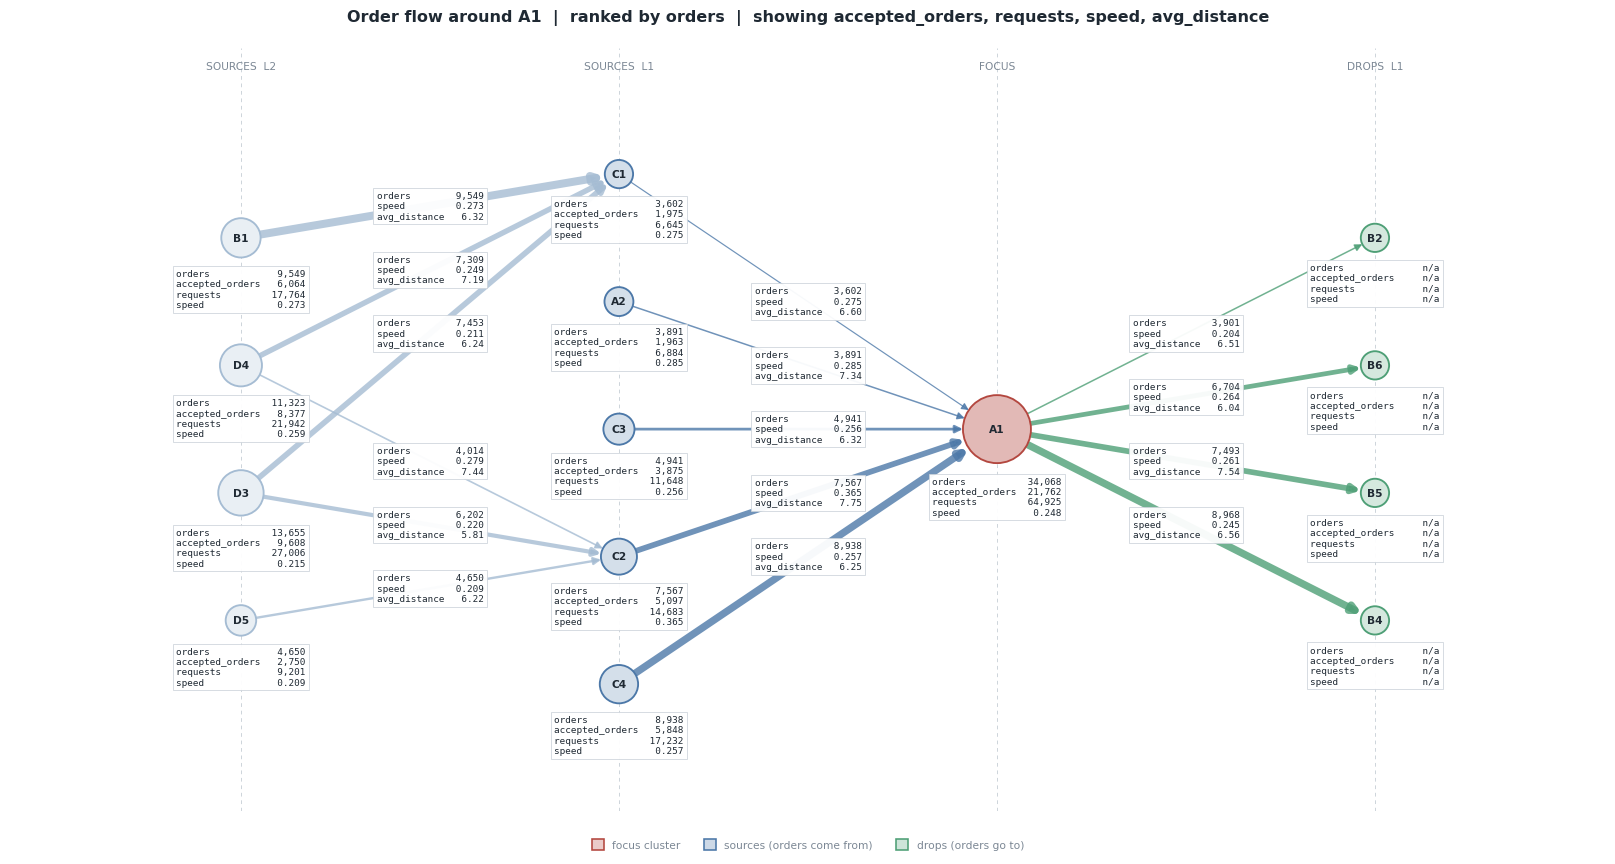

In [15]:
ex.plot(
    'A1',
    upstream=[5, 3, 2],
    downstream=[4, 2],
    node_metrics=['orders', 'accepted_orders', 'requests', 'speed'],
    edge_metrics=['orders', 'speed', 'avg_distance'],
)

### Top x by route, or top x by cluster

The same `top x` answers two different questions, and you pick which per call:

* `rank_by="edge"` (the default) keeps the biggest **routes** into the focus.
* `rank_by="node"` keeps the biggest **clusters**, however small the route
  between them happens to be.

A big cluster that sends the focus very little makes the second list and not the
first; a small cluster that happens to send a lot makes the first and not the
second.

In [16]:
print("top 4 sources of A1")
print()
print("  rank_by='edge'  - the biggest routes into A1")
for name, value in ex.graph.top_sources('A1', top=4, rank_by='edge'):
    print(f"     {name:<4} route into A1 = {value:>9,.0f}")
print()
print("  rank_by='node'  - the biggest clusters that feed A1")
for name, value in ex.graph.top_sources('A1', top=4, rank_by='node'):
    print(f"     {name:<4} cluster total = {value:>9,.0f}")

top 4 sources of A1

  rank_by='edge'  - the biggest routes into A1
     C4   route into A1 =     8,938
     C2   route into A1 =     7,567
     C3   route into A1 =     4,941
     A2   route into A1 =     3,891

  rank_by='node'  - the biggest clusters that feed A1
     C1   cluster total =    39,090
     C2   cluster total =    25,475
     C4   cluster total =     8,938
     A2   cluster total =     5,584


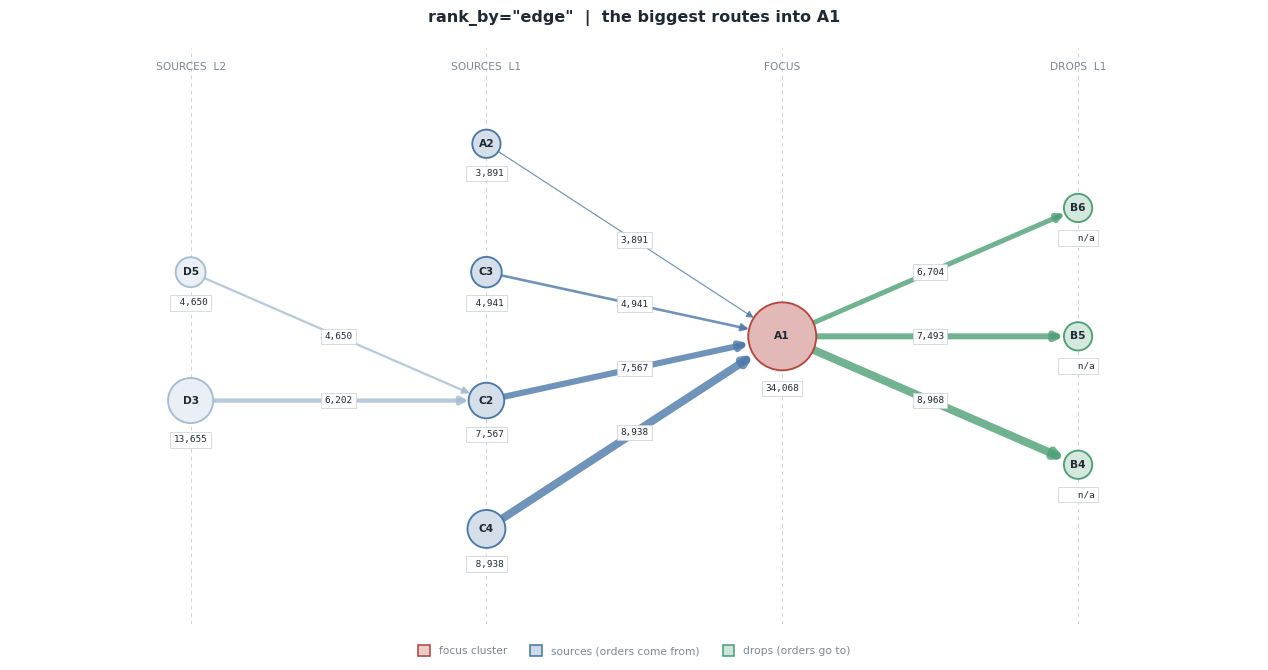

In [17]:
ex.plot('A1', upstream=[4, 2], downstream=3, rank_by='edge',
        node_metrics=['orders'], edge_metrics=['orders'],
        title='rank_by="edge"  |  the biggest routes into A1')

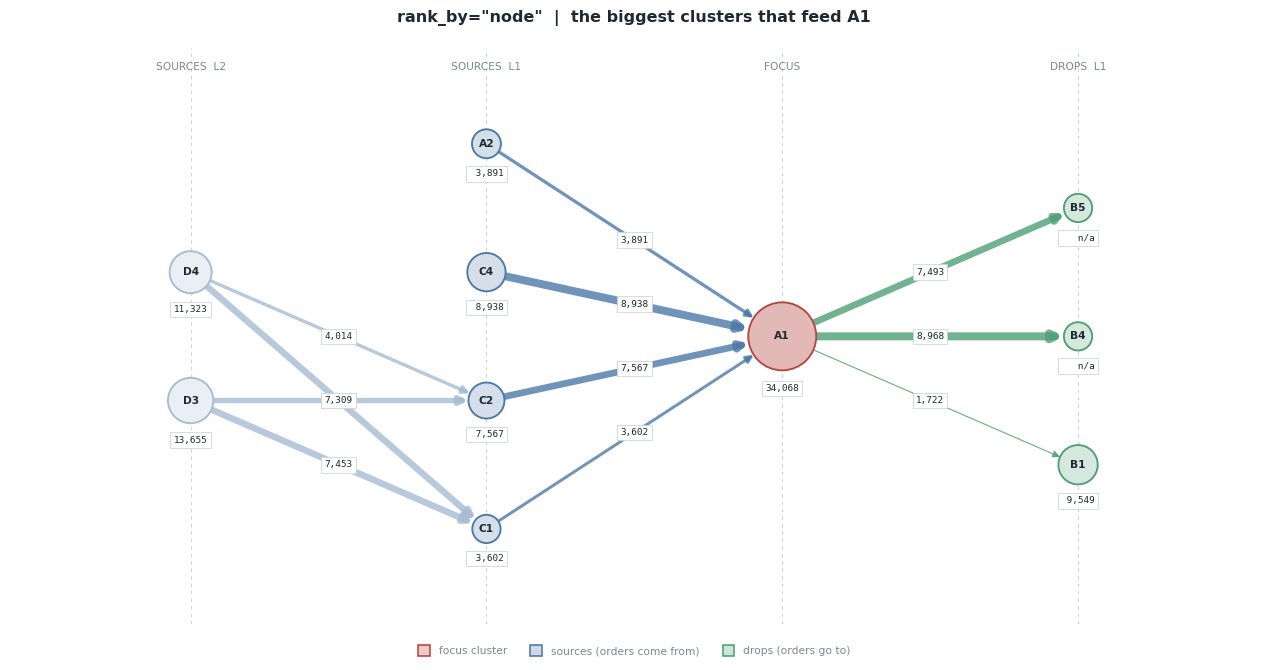

In [18]:
ex.plot('A1', upstream=[4, 2], downstream=3, rank_by='node',
        node_metrics=['orders'], edge_metrics=['orders'],
        title='rank_by="node"  |  the biggest clusters that feed A1')

Edge width and the edge tables always show the route's own metric, whichever
basis you rank on; when you rank by node the value that drove the selection is
kept on the edge as `rank_value`. `node_direction=` picks which side of a
cluster is measured - `"out"` for the biggest senders, `"in"` for the biggest
receivers.

The number in each node table is that cluster **as a pickup** - the orders it
sends out, across all of its routes, not just the ones drawn. Edge labels are a
different thing: the metric on that one route. `node_direction="in"` or
`"both"` switches what the node measures.

In [19]:
cell = 'C1'
print(f"{cell} as a pickup (what the node shows):"
      f" {ex.graph.node_value(cell, 'orders', 'out'):>10,.0f}")
print(f"{cell} as a drop                        :"
      f" {ex.graph.node_value(cell, 'orders', 'in'):>10,.0f}")
print(f"{cell} both sides                       :"
      f" {ex.graph.node_value(cell, 'orders', 'both'):>10,.0f}")
print()
print(f"the single route {cell} -> A1 is only   :"
      f" {ex.value(cell, 'A1', 'orders'):>10,.0f}   <- the edge label")

C1 as a pickup (what the node shows):      3,602
C1 as a drop                        :     35,488
C1 both sides                       :     39,090

the single route C1 -> A1 is only   :      3,602   <- the edge label


### Everything the top x left out

A picture of the top few reads as though it were the whole story. `rest=True`
adds one node per parent standing for every partner that did not make the cut,
so the drawing accounts for the full total instead of an arbitrary slice.

Its numbers come from merging the left-out routes: sums are summed, and
averages are re-weighted by the weight column rather than averaged again. The
result is exactly what those routes would give if they were one route, and two
routes that share a pickup and a drop fold together the same way.

In [20]:
inbound = ex.graph.node_value('A1', 'orders', 'in')
top3 = ex.graph.top_sources('A1', top=3, rank_by='edge')
drawn = sum(value for _, value in top3)

sub = ex.graph.flow_subgraph('A1', upstream=3, downstream=0,
                             metric='orders', rest=True)
rest = [data for _, data in sub.nodes(data=True) if data.get('is_rest')][0]

print(f"every route into A1 : {inbound:>12,.1f}")
print(f"the top 3 drawn     : {drawn:>12,.1f}   {[n for n, _ in top3]}")
print(f"the rest node       : {rest['value']:>12,.1f}   "
      f"{rest['routes']} routes from {rest['partners']}")
print(f"top 3 + rest        : {drawn + rest['value']:>12,.1f}")

every route into A1 :     35,151.2
the top 3 drawn     :     21,445.7   ['C4', 'C2', 'C3']
the rest node       :     13,705.5   4 routes from ['A2', 'C1', 'C6', 'C5']
top 3 + rest        :     35,151.2


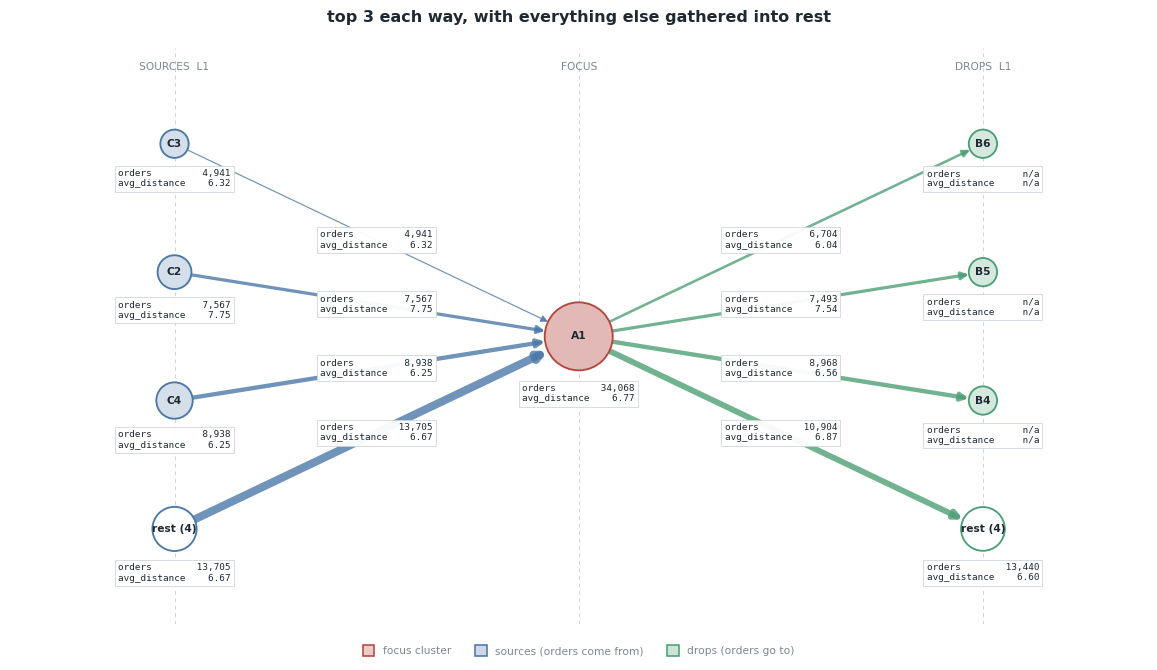

In [21]:
ex.plot('A1', upstream=3, downstream=3, rest=True,
        node_metrics=['orders', 'avg_distance'],
        edge_metrics=['orders', 'avg_distance'],
        title='top 3 each way, with everything else gathered into rest')

The average on the rest edge is weighted by the weight column, which is not the
same as averaging the numbers again. Checked against the raw rows:

In [22]:
rows = df[df.pickup_cluster.isin(rest['partners']) & (df.drop_cluster == 'A1')]
by_hand = (rows.avg_distance * rows.requests).sum() / rows.requests.sum()

print('rest edge avg_distance :', round(rest['metrics']['avg_distance'], 6))
print('weighted, by hand      :', round(by_hand, 6))
print('a flat mean of the rows:', round(rows.avg_distance.mean(), 6), ' <- what it is not')

rest edge avg_distance : 6.670704
weighted, by hand      : 6.670704
a flat mean of the rows: 6.699849  <- what it is not


The table drawn *on* the rest node follows the same rule as every other node:
it measures those clusters as a side of the graph, not the routes into the
focus. `clusters_summary` is that merge on its own. Here the two agree, because
in this frame the left-out clusters send nowhere except `A1` - feed them a
second destination and the node table would climb while the edge stayed put.

In [23]:
side = ex.graph.clusters_summary(rest['partners'], direction='out')
print('the left-out clusters, merged as pickups:')
for name in ('orders', 'requests', 'avg_distance'):
    print(f'   {name:<14} {side[name]:>12,.3f}')

the left-out clusters, merged as pickups:
   orders           13,705.469
   requests         26,155.419
   avg_distance          6.671


### Narrowing it down

`where(...)` restricts the grain buckets and `using(...)` changes the default
metric. Both return a new view over the same graph, so nothing is rebuilt.

Here the ranking, the tables and the number formats are all different.

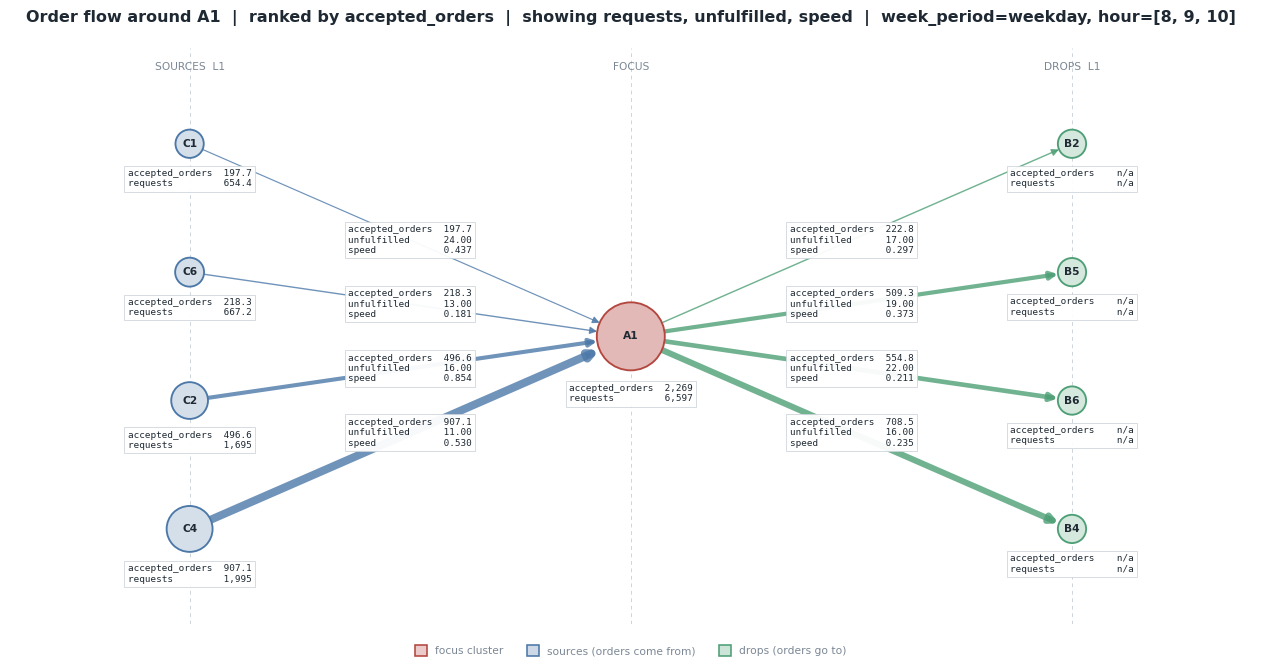

In [24]:
peak = ex.where(week_period='weekday', hour=[8, 9, 10])

peak.plot(
    'A1',
    upstream=4,
    downstream=4,
    metric='accepted_orders',                       # what the ranking uses
    node_metrics=['accepted_orders', 'requests'],   # what the node tables show
    edge_metrics=['accepted_orders', 'unfulfilled', 'speed'],
    value_format={'speed': '{:.3f}'},               # per-metric formats
)

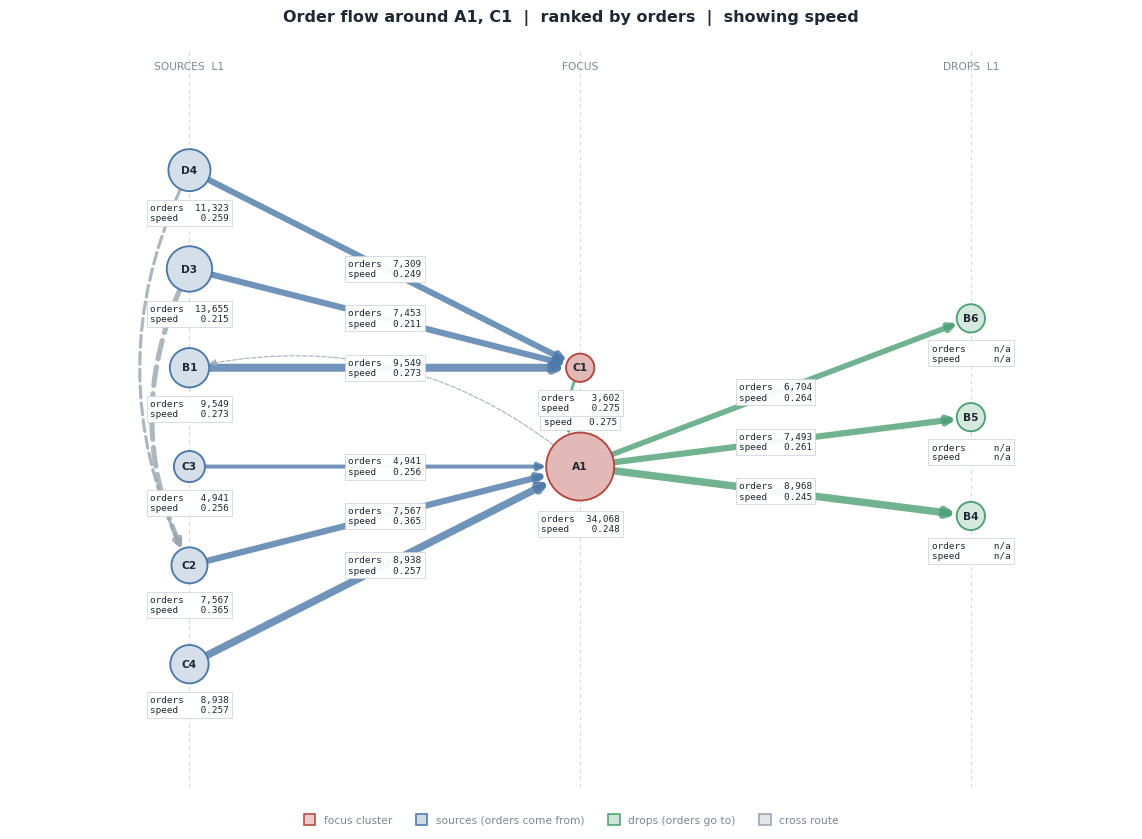

In [25]:
# two focus clusters at once, including the routes between the selected set
ex.plot(
    ['A1', 'C1'],
    upstream=3,
    downstream=3,
    include_cross_edges=True,
    node_metrics=['orders', 'speed'],
    edge_metrics=['orders', 'speed'],
)

### What a cluster holds, in and out

A cluster stores nothing of its own: its totals come from merging the tensors of
the routes touching it. Sums are summed, means are weighted by the weight column
you chose, and the difference is opt-in per metric.

In [26]:
print('averages are weighted by:', ex.weight_col)
print()
for metric, sides in ex.node_split('A1', metrics=['orders', 'requests', 'avg_distance'],
                                   diff=True).items():
    print(f"  {metric:<13} in={sides['in']:>10,.2f}  out={sides['out']:>10,.2f}"
          f"  diff={sides['diff']:>10,.2f}")

averages are weighted by: requests

  orders        in= 35,151.16  out= 34,068.27  diff= -1,082.90
  requests      in= 69,719.15  out= 64,925.19  diff= -4,793.96
  avg_distance  in=      6.74  out=      6.77  diff=      0.03


In [27]:
# across the graph, choosing the metrics and which of them get a difference
display(ex.node_metrics_frame(metrics=['orders', 'avg_distance'],
                              diff=['orders']).round(2).head(6))
print('NaN means no routes on that side at all, which is not zero orders.')

  cluster  in_routes  out_routes  in_orders  out_orders  diff_orders  in_avg_distance  out_avg_distance
0      A1          7           7   35151.16    34068.27     -1082.90             6.74              6.77
1      D3          0           2        NaN    13655.06          NaN              NaN              6.02
2      D4          0           2        NaN    11322.69          NaN              NaN              7.28
3      B1          1           1    1722.50     9548.98      7826.48             7.74              6.32
4      C4          0           1        NaN     8937.68          NaN              NaN              6.25
5      C2          4           1   17907.85     7567.31    -10340.54             6.39              7.75
NaN means no routes on that side at all, which is not zero orders.


### A cluster that is on both sides

A cluster often both feeds the focus and is fed by it. Drawn once it has to sit
on one side, and the other side's routes then point backwards across the
figure. Instead it is **split**: one copy upstream, one copy downstream, so
everything reads left to right. A cluster reached twice on the *same* side is
still drawn once.

In [28]:
observation = pd.DataFrame([
    {'pickup_cluster': u, 'drop_cluster': v, 'orders': 10.0 * (i + 1),
     'requests': 20.0, 'avg_distance': 3.0, 'avg_duration': 12.0}
    for i, (u, v) in enumerate([
        ('B2', 'Exp'), ('A1', 'B2'), ('A2', 'B2'), ('A3', 'B2'),
        ('Exp', 'A1'), ('Exp', 'B1'), ('Exp', 'B2'), ('B1', 'A2'), ('B1', 'C1')])
])
obs = RouteExplorer(observation)

for mirror in (False, True):
    sub = obs.graph.flow_subgraph('Exp', upstream=[3, 3], downstream=[3, 3], mirror=mirror)
    backwards = [(u, v) for u, v in sub.edges()
                 if sub.nodes[u]['level'] > sub.nodes[v]['level']]
    print(f'mirror={str(mirror):<5} nodes={sub.number_of_nodes()}  '
          f'routes pointing backwards: {len(backwards)}')

mirror=False nodes=7  routes pointing backwards: 3
mirror=True  nodes=9  routes pointing backwards: 0


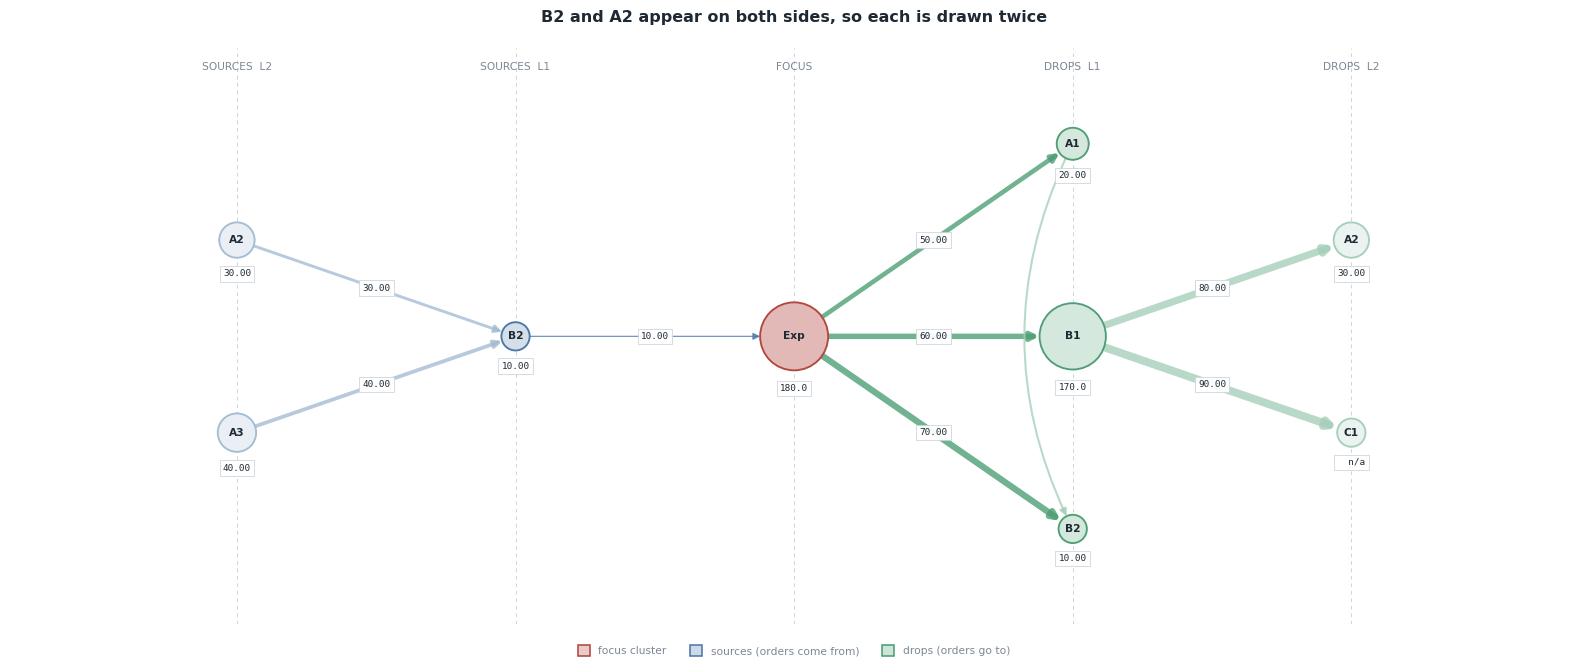

In [29]:
obs.plot('Exp', upstream=[3, 3], downstream=[3, 3],
         node_metrics=['orders'], edge_metrics=['orders'],
         title='B2 and A2 appear on both sides, so each is drawn twice')

### Metrics you derive rather than store

`derived_metrics` builds a metric out of the others, computed **after** the
aggregation for whatever is in scope. A ratio of totals is not the mean of the
ratios, and only the first is meaningful once buckets, routes and clusters are
collapsed together.

In [30]:
rates = RouteExplorer(
    df,
    grain_cols=('week_period', 'hour'),
    derived_metrics={
        'fill_rate': ('accepted_orders', '/', 'orders'),   # a ratio, after totalling
        'lost': ('orders', '-', 'accepted_orders'),        # a difference
    },
)
route = ('A1', 'B1')
print('for one route, weekday 8am :',
      round(rates.value(*route, 'fill_rate', week_period='weekday', hour=[8]), 4))
print('the same route, whole week :', round(rates.value(*route, 'fill_rate'), 4))
print('  = accepted', round(rates.value(*route, 'accepted_orders'), 1),
      '/ orders', round(rates.value(*route, 'orders'), 1))
print()
print('and it behaves like any other metric:')
print('  cluster A1 inbound  :', round(rates.node_split('A1', metrics=['fill_rate'])['fill_rate']['in'], 4))
print('  whole graph         :', round(rates.summary()['fill_rate'], 4))
print('  ranked, top 3       :', rates.top_routes(3, metric='fill_rate')['fill_rate'].round(3).tolist())
print('  as a filter         :', len(rates.keep(edge_filter={'fill_rate': ('>', 0.45)}).routes),
      'of', len(rates.routes), 'routes above 0.45')

for one route, weekday 8am : 0.5027
the same route, whole week : 0.7649
  = accepted 1317.6 / orders 1722.5

and it behaves like any other metric:
  cluster A1 inbound  : 0.6608
  whole graph         : 0.675
  ranked, top 3       : [0.828, 0.822, 0.81]
  as a filter         : 23 of 23 routes above 0.45


## 5. Filtering

Top-k and filtering are different things. `upstream` / `downstream` **rank** on
one metric and keep the best few at each hop. A filter is an **absolute test**
on any metric: whatever fails it is gone, however highly it ranks.

`keep()` returns a new graph and leaves the original alone; `cut()` prunes the
one you have. A test is a number (meaning `>=`), an `(operator, value)` pair or
a `(low, high)` range, and several metrics are combined with AND.

In [31]:
# thresholds taken from the data, so the demo means something
speeds = np.array([ex.value(u, v, 'speed') for u, v in ex.routes])
volumes = np.array([ex.value(u, v, 'orders') for u, v in ex.routes])
mid_speed, mid_orders = np.median(speeds).round(3), np.median(volumes).round()
print(f'median speed {mid_speed}, median orders {mid_orders:,.0f}')
print()
print('all routes                :', len(ex.routes))
print('speed above median        :', len(ex.keep(edge_filter={'speed': ('>', mid_speed)}).routes))
print('orders above median       :', len(ex.keep(edge_filter={'orders': mid_orders}).routes))
print('both at once (AND)        :', len(ex.keep(edge_filter={'orders': mid_orders,
                                                             'speed': ('>', mid_speed)}).routes))
print('speed inside a range      :', len(ex.keep(edge_filter={'speed': (0.24, 0.28)}).routes))
print()
print('original is untouched     :', len(ex.routes), 'routes')

median speed 0.26, median orders 4,650

all routes                : 23
speed above median        : 12
orders above median       : 12
both at once (AND)        : 5
speed inside a range      : 12

original is untouched     : 23 routes


In [32]:
# node filters drop the cluster and every route touching it
totals = np.array([ex.graph.node_value(c, 'orders', 'both') for c in ex.clusters])
busy_enough = np.percentile(totals, 60).round()
busy = ex.keep(node_filter={'orders': busy_enough})
print(f'clusters with >= {busy_enough:,.0f} orders in or out:')
print(' ', len(ex.clusters), '->', len(busy.clusters), 'clusters,',
      len(ex.routes), '->', len(busy.routes), 'routes')
print(' ', sorted(busy.clusters))
print()
# preview what a filter would accept, without changing anything
print('routes that would survive a speed filter:')
print(' ', ex.matching_routes(edge_filter={'speed': ('>', mid_speed)})[:6])

clusters with >= 8,071 orders in or out:
  20 -> 8 clusters, 23 -> 10 routes
  ['A1', 'B1', 'B4', 'C1', 'C2', 'C4', 'D3', 'D4']

routes that would survive a speed filter:
  [('A1', 'B5'), ('A1', 'B6'), ('A1', 'A2'), ('B1', 'C1'), ('C1', 'A1'), ('C2', 'A1')]


In [33]:
# filters honour the sticky grain: the same test, two different windows
morning = ex.where(week_period='weekday', hour=[8, 9, 10])
peak_orders = np.median([morning.value(u, v, 'orders') for u, v in ex.routes]).round()
print(f'test: orders >= {peak_orders:,.0f}')
print('  counted over weekday 08-10:', len(morning.keep(edge_filter={'orders': peak_orders}).routes))
print('  counted over the whole week:', len(ex.keep(edge_filter={'orders': peak_orders}).routes))
print()
# cut() is the mirror of keep(), and works in place
pruned = RouteExplorer(df)
print('before cutting the thin routes:', len(pruned.routes))
pruned.cut(edge_filter={'orders': ('<', mid_orders)})
print('after                         :', len(pruned.routes))

test: orders >= 384
  counted over weekday 08-10: 12
  counted over the whole week: 23

before cutting the thin routes: 23
after                         : 12


Plots and expansions take the same arguments, applied *before* walking, so the
top-k at each hop is chosen from whatever survived the filter.

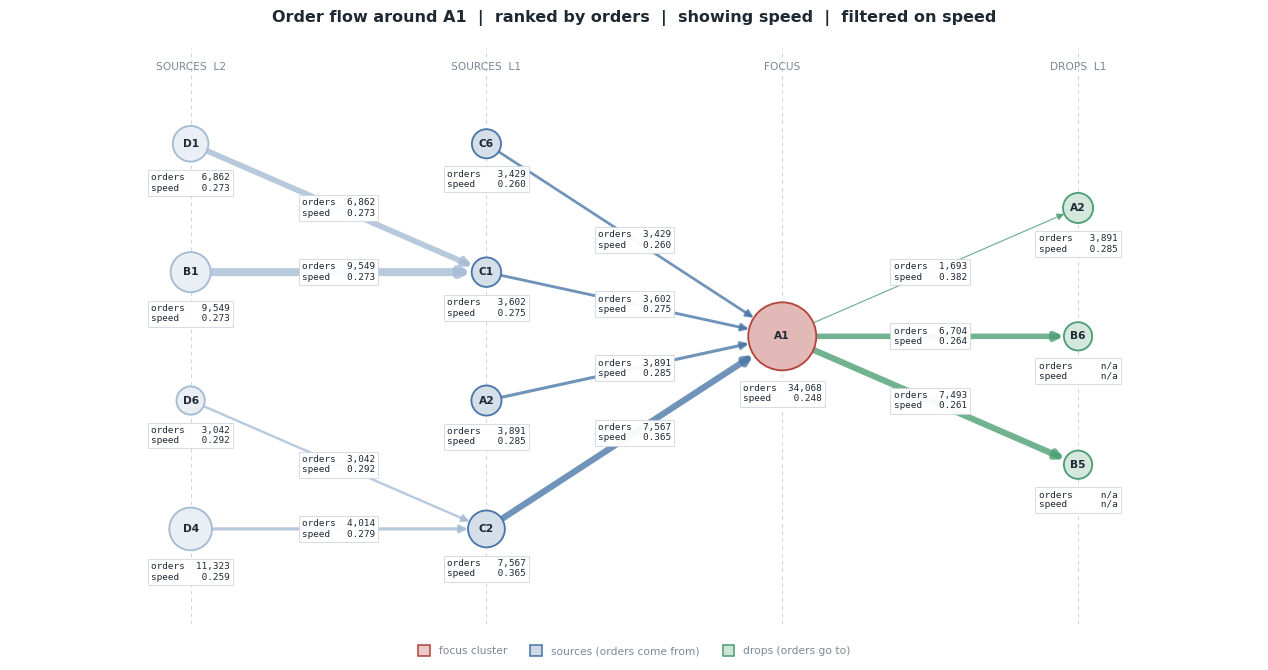

In [34]:
ex.plot(
    'A1',
    upstream=[4, 2],
    downstream=3,
    edge_filter={'speed': ('>', mid_speed)},   # only above-median speed
    node_metrics=['orders', 'speed'],
    edge_metrics=['orders', 'speed'],
)

## 6. Reachability: what can get here, and how fast

Filtering asks *is this route good enough*. Reachability asks *can I get there
at all, and at what cost*. The cost is summed along the path, so a travel-time
budget is just a cap on the ride-time metric.

The demo durations are minutes, so `budget=120` reads as **within two hours**.

In [35]:
near = ex.reach_to('A1', budget=120, max_hops=3)
print('clusters that can reach A1 within 120 minutes:')
display(near.round(1))

clusters that can reach A1 within 120 minutes:
   cluster  avg_duration  hops            path
0       C2          21.3     1        C2 -> A1
1       C1          24.0     1        C1 -> A1
2       C4          24.3     1        C4 -> A1
3       C5          24.4     1        C5 -> A1
4       C3          24.7     1        C3 -> A1
5       A2          25.7     1        A2 -> A1
6       C6          26.2     1        C6 -> A1
7       D6          43.7     2  D6 -> C2 -> A1
8       B1          47.2     2  B1 -> C1 -> A1
9       D3          47.6     2  D3 -> C2 -> A1
10      D4          47.9     2  D4 -> C2 -> A1
11      D1          50.5     2  D1 -> C1 -> A1
12      D2          50.8     2  D2 -> C1 -> A1
13      D5          51.0     2  D5 -> C2 -> A1


In [36]:
# budgets taken from the data, so the caps visibly bite
cost = ex.schema.ride_time_metric
tight = round(ex.reach_to('A1', max_hops=1)[cost].median())
legs = np.median([ex.value(u, v, 'orders') for u, v in ex.routes]).round()

print(f'budget 120 min, up to 3 hops  :', len(ex.reach_to('A1', budget=120, max_hops=3)))
print(f'budget {tight:>3} min, up to 3 hops  :', len(ex.reach_to('A1', budget=tight, max_hops=3)))
print(f'budget 120 min, only 1 hop     :', len(ex.reach_to('A1', budget=120, max_hops=1)))
print(f'budget 120 min, 2 hops or more :', len(ex.reach_to('A1', budget=120, max_hops=3, min_hops=2)))
print()
print('plenty of time is not the same as few legs: the caps are independent')
print()
# a leg has to earn its place too
print(f'budget 120 min, every leg >= {legs:,.0f} orders:',
      len(ex.reach_to('A1', budget=120, max_hops=3, edge_filter={'orders': legs})))

budget 120 min, up to 3 hops  : 14
budget  24 min, up to 3 hops  : 2
budget 120 min, only 1 hop     : 7
budget 120 min, 2 hops or more : 7

plenty of time is not the same as few legs: the caps are independent

budget 120 min, every leg >= 4,650 orders: 5


In [37]:
# the other direction, and a different cost entirely
print('where can A1 reach within 30 minutes:')
display(ex.reach_from('A1', budget=30).round(1))
print()

print('and within 7 distance units, counting km instead of minutes:')
display(ex.reach_from('A1', budget=7, cost='avg_distance').round(1))

where can A1 reach within 30 minutes:
  cluster  avg_duration  hops      path
0      A2          20.3     1  A1 -> A2
1      B6          22.8     1  A1 -> B6
2      B4          26.7     1  A1 -> B4
3      B5          28.9     1  A1 -> B5

and within 7 distance units, counting km instead of minutes:
  cluster  avg_distance  hops      path
0      B6           6.0     1  A1 -> B6
1      B3           6.3     1  A1 -> B3
2      B2           6.5     1  A1 -> B2
3      B4           6.6     1  A1 -> B4


In [38]:
# reach_to keeps the best way in; paths() lists the alternatives
start = near['cluster'].iloc[-1]
print(f'every route from {start} to A1 inside the budget:')
display(ex.paths(start, 'A1', budget=120, max_hops=3, metrics=['orders'])
          .drop(columns=['clusters']).round(1))
best = ex.paths(start, 'A1', budget=120).iloc[0]['clusters']
print('total minutes on the best one:',
      round(ex.path_total(best, 'avg_duration'), 1))

every route from D5 to A1 inside the budget:
             path  hops  avg_duration   orders
0  D5 -> C2 -> A1     2          51.0  12217.5
total minutes on the best one: 51.0


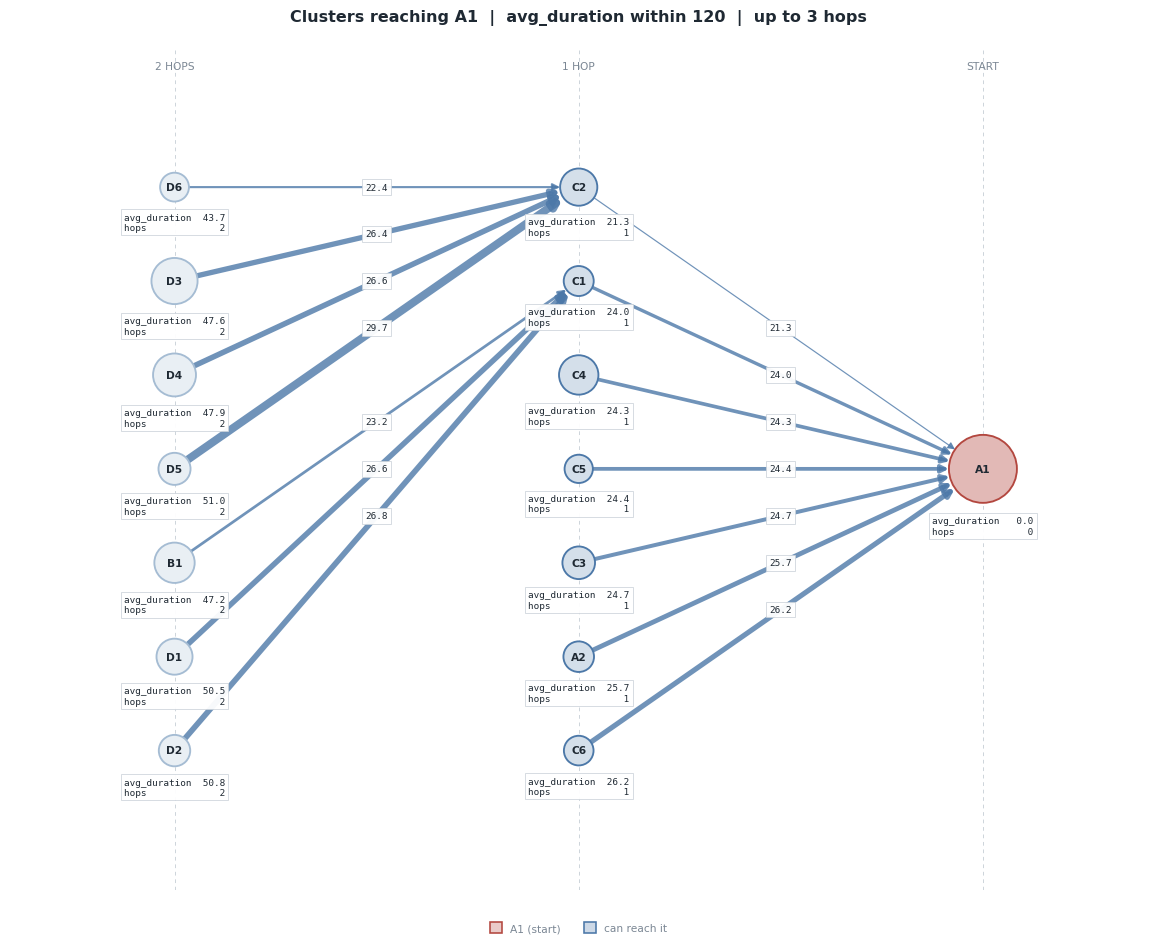

In [39]:
ex.plot_reach('A1', budget=120, max_hops=3)

Columns are hop bands, node tables carry the **accumulated** cost of getting
there, and edge labels carry the cost of that single leg. Node size is the
cluster's own volume, so you can see at a glance which of the places that can
reach A1 in time are actually worth anything.

## 7. Supporting views

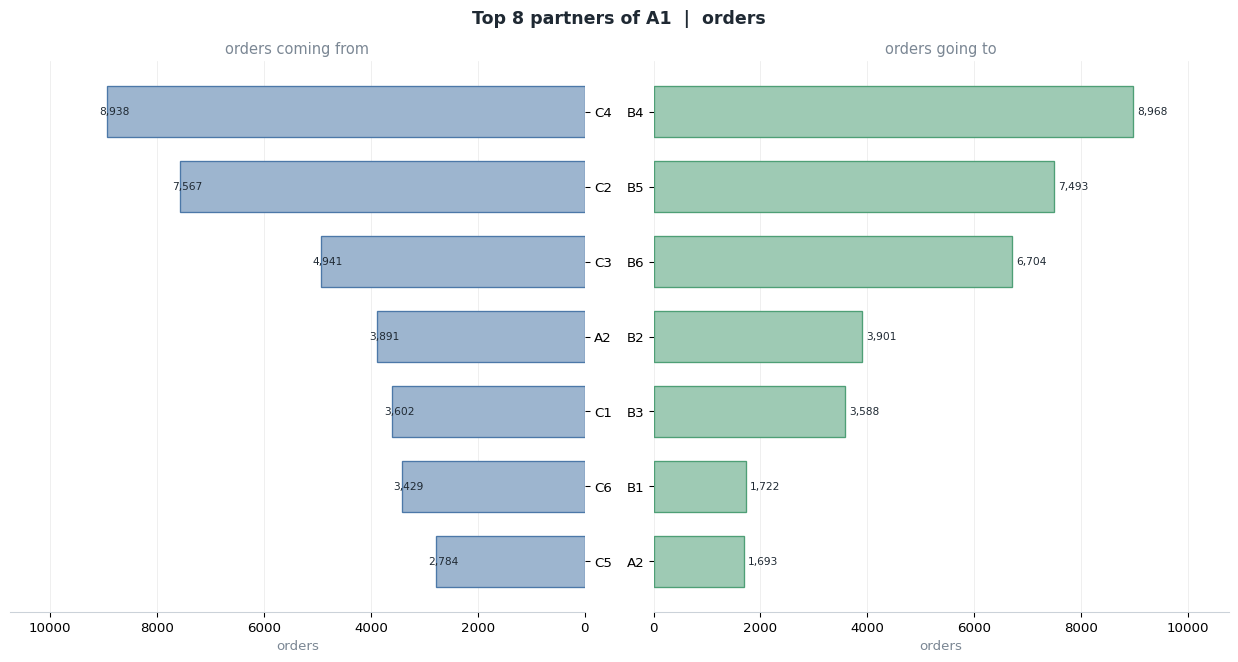

In [40]:
ex.plot_partners('A1', top=8)      # both panels share one scale

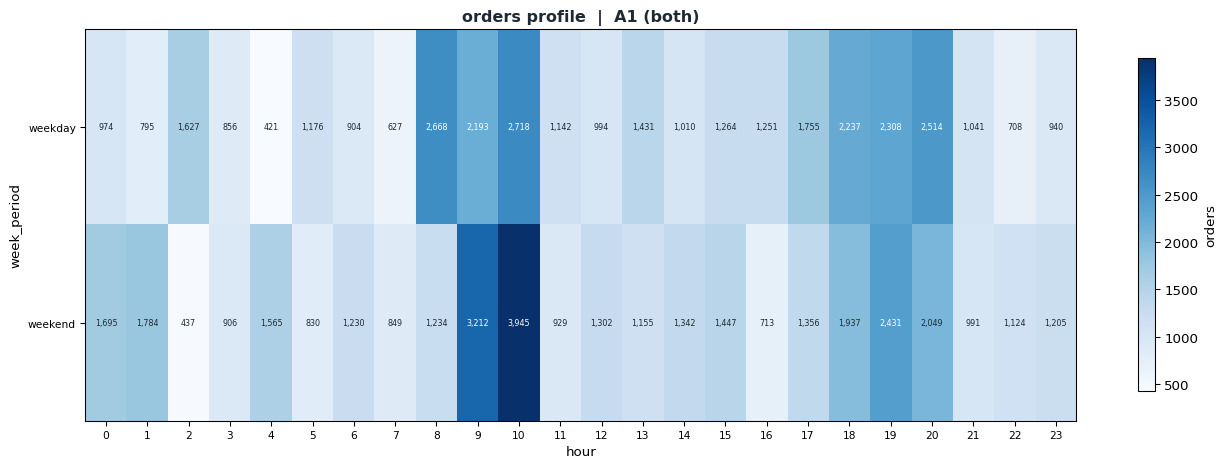

In [41]:
ex.plot_profile(cluster='A1', metric='orders')     # week_period x hour

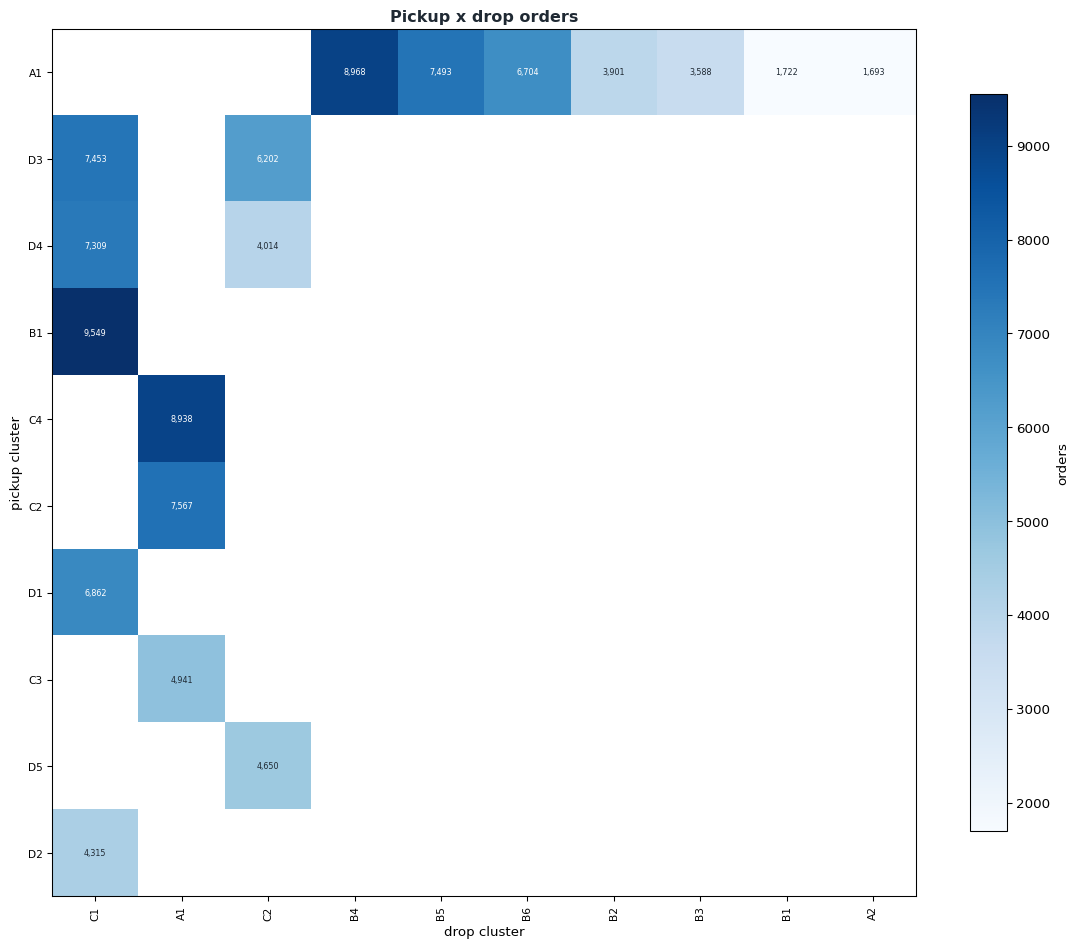

In [42]:
ex.plot_matrix(top=10)             # pickup x drop

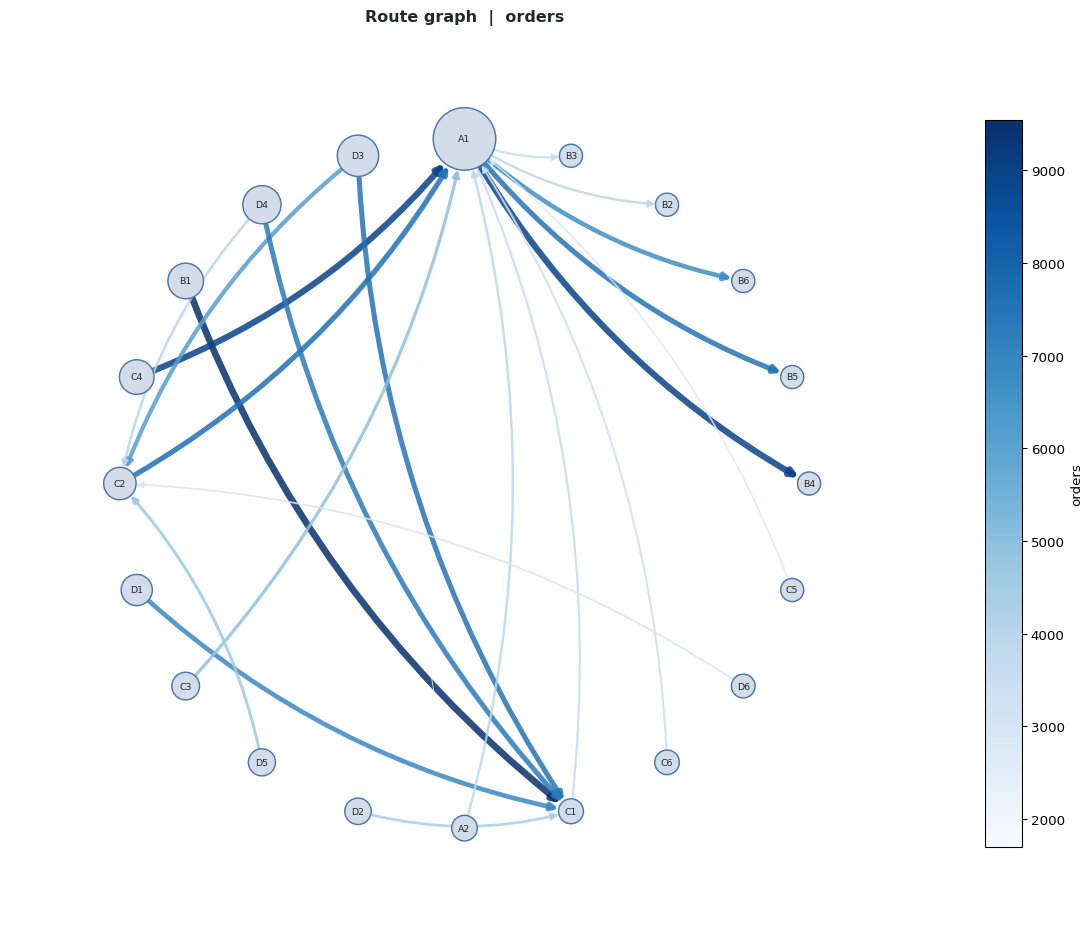

In [43]:
ex.plot_graph(top_routes=25)       # clusters ranked around the ring

### Tables rather than pictures

Everything above is available as a DataFrame.

In [44]:
print('routes ranked by the default metric')
display(ex.top_routes(6).round(1))

print('per cluster: inbound vs outbound and the net balance')
display(ex.clusters_frame().head(6).round(1))

routes ranked by the default metric
  pickup_cluster drop_cluster  orders  routes  coverage
0             B1           C1  9549.0       1       0.8
1             A1           B4  8968.0       1       0.8
2             C4           A1  8937.7       1       0.7
3             C2           A1  7567.3       1       0.7
4             A1           B5  7492.8       1       0.8
5             D3           C1  7453.1       1       0.9
per cluster: inbound vs outbound and the net balance
  cluster  out_orders  in_orders      net  out_routes  in_routes  pickup_count  drop_count        cities
0      A1     34068.3    35151.2  -1082.9           7          7             7           7  north, south
1      D3     13655.1        NaN  13655.1           2          0             2           0  north, south
2      D4     11322.7        NaN  11322.7           2          0             2           0  north, south
3      B1      9549.0     1722.5   7826.5           1          1             1           1  north, 

In [45]:
print('one route, every metric:')
for name, value in ex.route('A1', 'B1').items():
    print(f'  {name:<18} {value:>12,.3f}')

one route, every metric:
  row_count                30.000
  orders                1,722.500
  requests              4,051.004
  accepted_orders       1,317.558
  unfulfilled             192.000
  supply_count            888.000
  avg_distance              7.743
  avg_duration             30.811
  accept_rate               0.645
  speed                     0.251


## 8. The DataFrame plotter

`sameer_graph_lib.plotter` is stateless: every function takes a DataFrame and
returns a figure. `mode` decides how several columns share the canvas, `group`
splits each series by a categorical column, `kind` picks the mark.

`ex.frame()` gives the long per-bucket frame to plot against.

In [46]:
long = ex.frame()
print(long.shape)
long.head(3)

(833, 15)


    route week_period  hour  row_count      orders    requests  accepted_orders  unfulfilled  supply_count  \
0  A1->B1     weekday     0        1.0   42.676297  147.793807        83.371301          6.0           5.0   
1  A1->B1     weekday     1        1.0   16.589792   45.428424         7.676679          4.0          47.0   
2  A1->B1     weekday     2        1.0  126.696616  238.044944        81.366701         11.0          21.0   

   avg_distance  avg_duration  accept_rate     speed pickup drop  
0      2.862626     53.731012     0.673130  0.053277     A1   B1  
1      8.538786     32.478638     0.790042  0.262905     A1   B1  
2      7.711751     18.970935     0.781322  0.406503     A1   B1  

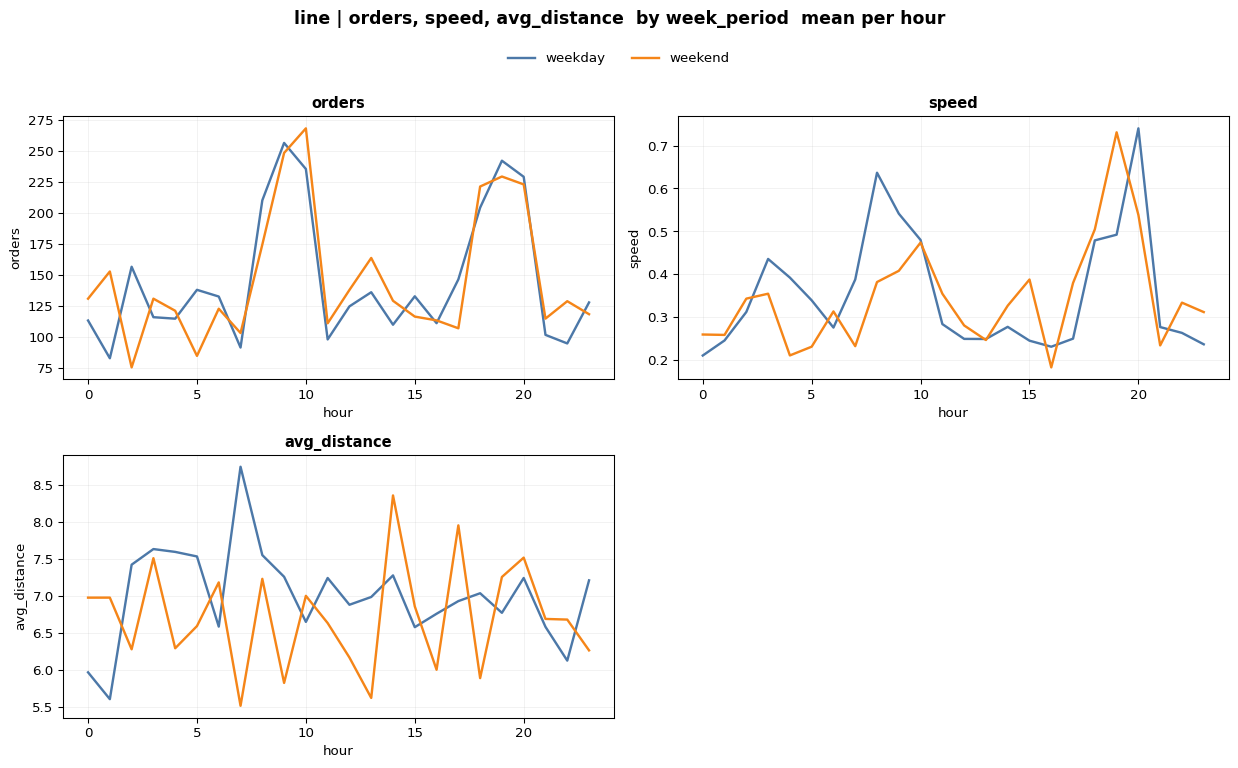

In [47]:
# one panel per column, weekday vs weekend overlaid in each
plotter.plot_columns(long, ['orders', 'speed', 'avg_distance'],
                     x='hour', group='week_period', agg='mean',
                     kind='line', mode='grid')

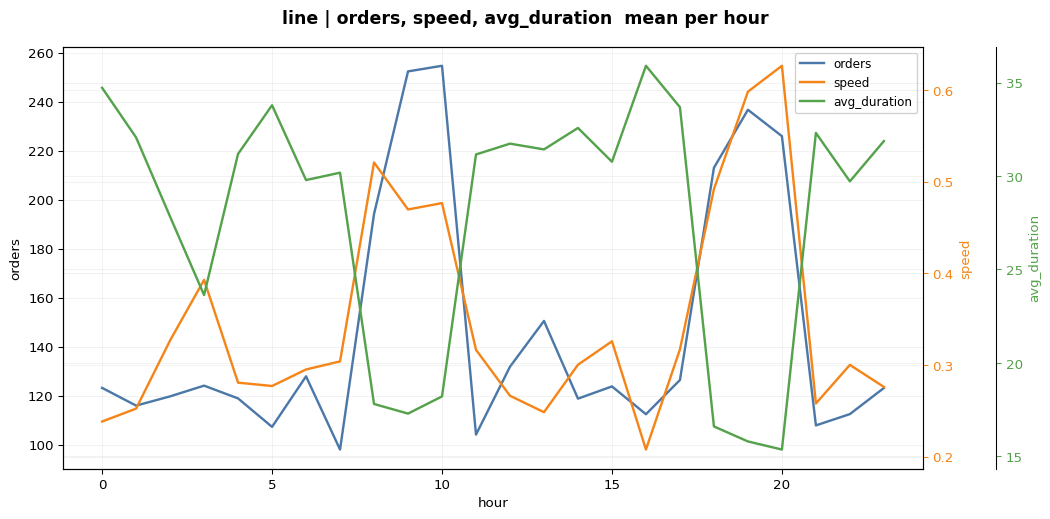

In [48]:
# columns with different scales on one chart, one y-axis each
plotter.plot_multi_axis(long, ['orders', 'speed', 'avg_duration'],
                        x='hour', agg='mean')

### Distributions

`plot_distribution` checks one column (and prints the numbers in the corner);
`compare_distributions` overlays the same variable for every group, one colour
per line.

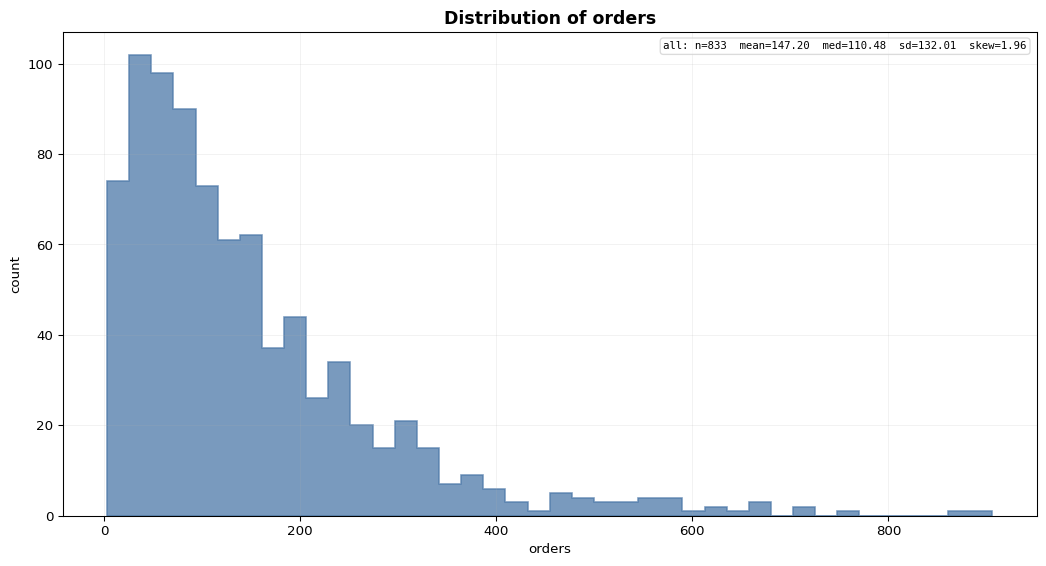

In [49]:
plotter.plot_distribution(long, 'orders', kind='hist', bins=40)

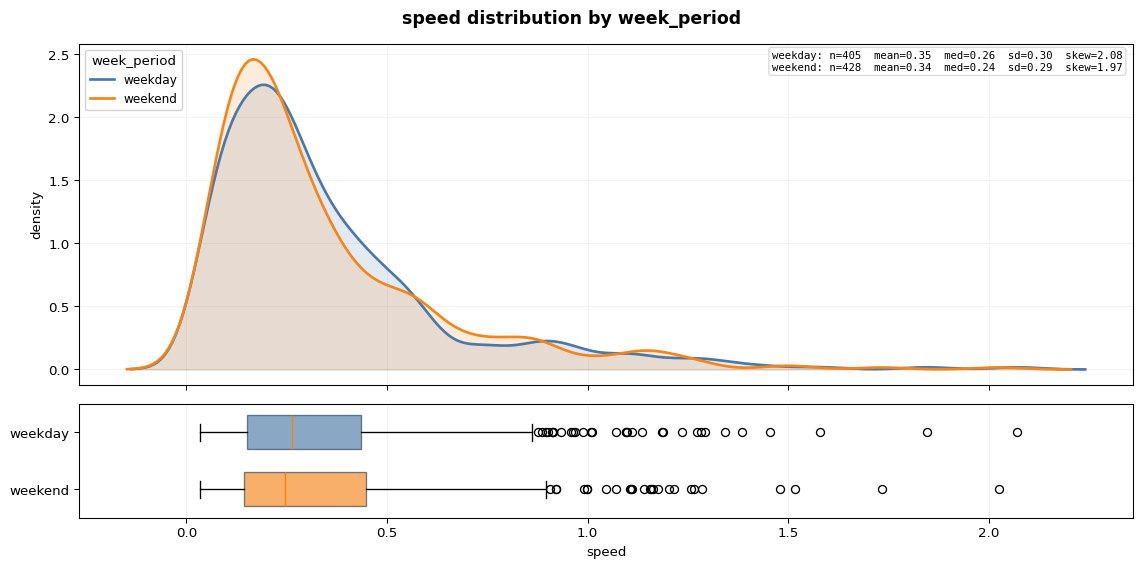

In [50]:
plotter.compare_distributions(long, 'speed', group='week_period',
                              kind='kde', with_box=True)

In [51]:
plotter.describe_distribution(long, 'speed', group='week_period').round(3)

     group  count  missing  n_unique   mean    std    min    max    iqr   skew  kurtosis  outlier_low  \
0  weekday    405        0       405  0.352  0.301  0.033  2.069  0.284  2.079     5.590       -0.274   
1  weekend    428        0       428  0.343  0.295  0.033  2.024  0.304  1.970     4.883       -0.312   

   outlier_high  outlier_share     p1    p25    p50    p75    p99  
0         0.863          0.079  0.042  0.152  0.264  0.436  1.382  
1         0.903          0.058  0.036  0.143  0.245  0.447  1.280  

### Comparing groups

`compare_groups` aggregates per group - the usual test vs control readout.
`normalize_to` expresses every group relative to one baseline.

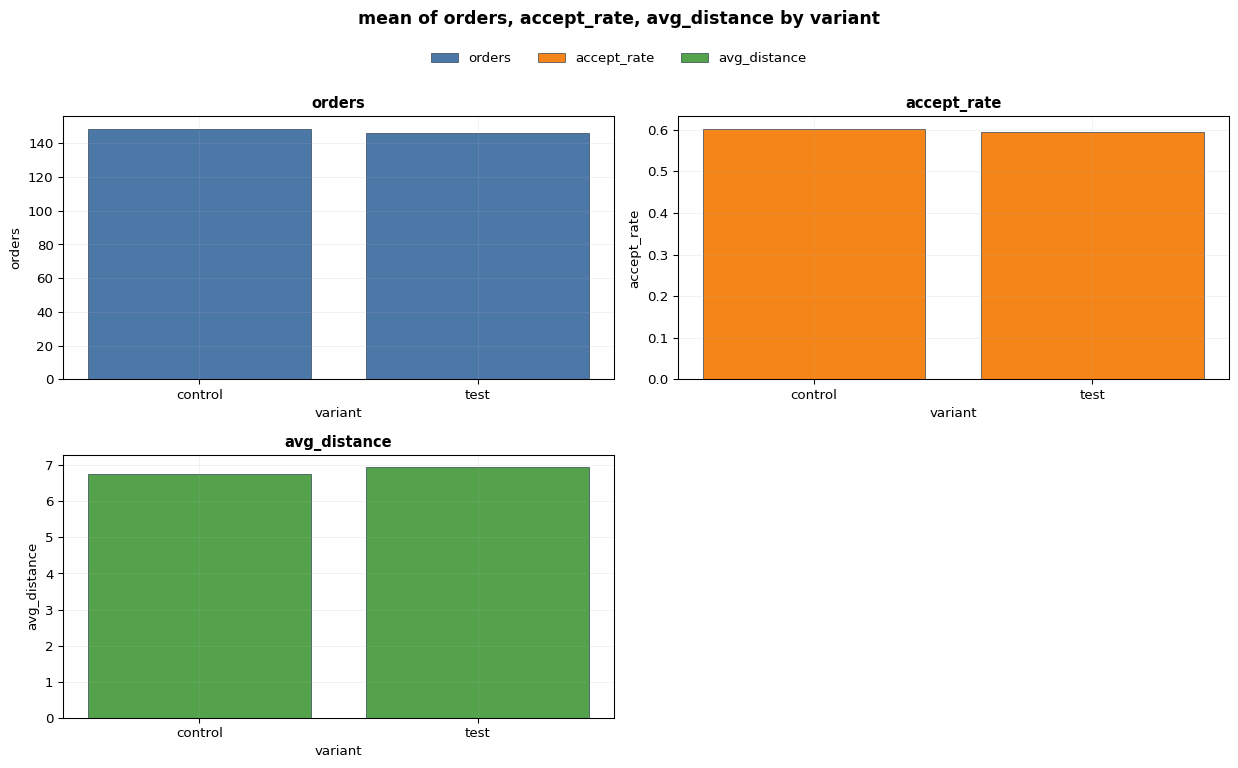

In [52]:
plotter.compare_groups(df, ['orders', 'accept_rate', 'avg_distance'],
                       group='variant', agg='mean')

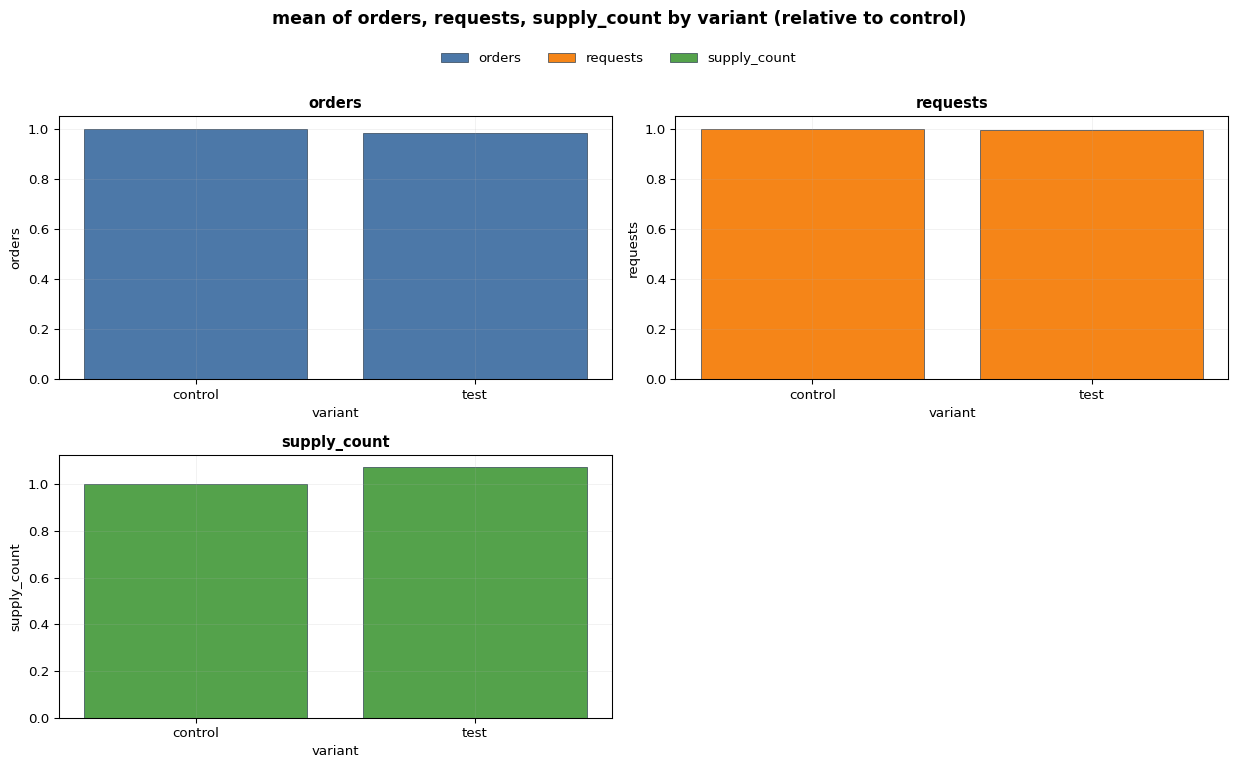

In [53]:
plotter.compare_groups(df, ['orders', 'requests', 'supply_count'],
                       group='variant', agg='mean', normalize_to='control')

In [54]:
plotter.group_stats(df, ['orders', 'avg_distance', 'accept_rate'],
                    group='variant').round(3)

   variant orders                           avg_distance                      accept_rate                \
            count     mean   median     std        count   mean median    std       count   mean median   
0  control    393  148.559  112.535  131.54          393  6.749  6.611  3.030         393  0.602  0.601   
1     test    440  145.981  106.162  132.57          440  6.943  6.878  2.957         440  0.595  0.600   

          
     std  
0  0.165  
1  0.166  

## 9. When you only have one hex column

Everything above needs a pickup and a drop on each row. Often the data is not
shaped that way: there is **one column of H3 cells** and the same metric
columns, with no route information at all.

`HexMetricGraph` keeps the metrics on the cells and takes the edges from the H3
array logic the library already uses - each cell is inserted with
`AffinityGraph.add_hex`, which attaches it to its nearest neighbours by grid
distance.

In [55]:
import h3
from sameer_graph_lib import HexMetricGraph

# one hex column plus the usual metrics: no pickup, no drop
rng2 = np.random.default_rng(4)
centre = h3.latlng_to_cell(12.935, 77.624, 8)
cells = sorted(h3.grid_disk(centre, 2))

hex_rows = []
for i, cell in enumerate(cells):
    for week_period in ('weekday', 'weekend'):
        for hour in (8, 9, 12, 18, 19):
            requests = float(rng2.integers(20, 300) * (1 + i % 4))
            hex_rows.append({
                'hexid': cell,
                'week_period': week_period,
                'hour': hour,
                'orders': requests * rng2.uniform(0.3, 0.7),
                'requests': requests,
                'unfulfilled': float(rng2.integers(0, 9)),
                'avg_distance': float(rng2.uniform(1, 9)),
                'avg_duration': float(rng2.uniform(5, 40)),
            })

hex_df = pd.DataFrame(hex_rows)
print(f'{len(hex_df):,} rows, {hex_df.hexid.nunique()} distinct cells, no route columns')
hex_df.head(3)

190 rows, 19 distinct cells, no route columns


             hexid week_period  hour      orders  requests  unfulfilled  avg_distance  avg_duration
0  8861892427fffff     weekday     8  112.510418     223.0          8.0      8.809950      7.829261
1  8861892427fffff     weekday     9   65.786817     146.0          5.0      7.415210     11.108474
2  8861892427fffff     weekday    12  108.173501     209.0          7.0      8.217721     21.700373

In [56]:
hg = HexMetricGraph(hex_df, hex_col='hexid', grain_cols=('week_period', 'hour'))
print(hg)
print()
print(hg.describe())

HexMetricGraph(cells=19, edges=42, res=8, topology='attach', value_metric='orders')

cells         : 19
edges         : 42 (attach)
resolution    : 8
rows folded in: 190
grains        : week_period (2), hour (24)
metrics       : 7, value metric 'orders'


In [57]:
cell = hg.top_cells('orders', 1)['hex'].iloc[0]
print('busiest cell:', cell)
print('  orders all week :', round(hg.value(cell, 'orders'), 1))
print('  orders 08-09    :', round(hg.value(cell, 'orders', hour=[8, 9]), 1))
print('  neighbours      :', len(hg.neighbors(cell)))
print()
print('top cells:')
display(hg.top_cells('orders', 5).round(1))

busiest cell: 88618925c9fffff
  orders all week : 4470.2
  orders 08-09    : 1799.7
  neighbours      : 4

top cells:
               hex  rows  degree  orders
0  88618925c9fffff    10       4  4470.2
1  88618925c1fffff    10       6  4420.2
2  8861892517fffff    10       4  4171.8
3  88618925c7fffff    10       6  3343.2
4  88618925e1fffff    10       4  3153.3


In [58]:
# the per-cell metric is written onto the node, so the corridor selection that
# already exists in the library can weight by it
corridor = hg.corridor(0.8)
stats = hg.corridor_stats(0.8)
print(f'{len(corridor)} of {len(hg)} cells hold {stats['value_coverage_pct']}% of the orders')
print(f'covering {stats['area_km2']} km2')

14 of 19 cells hold 80.04% of the orders
covering 10.64 km2


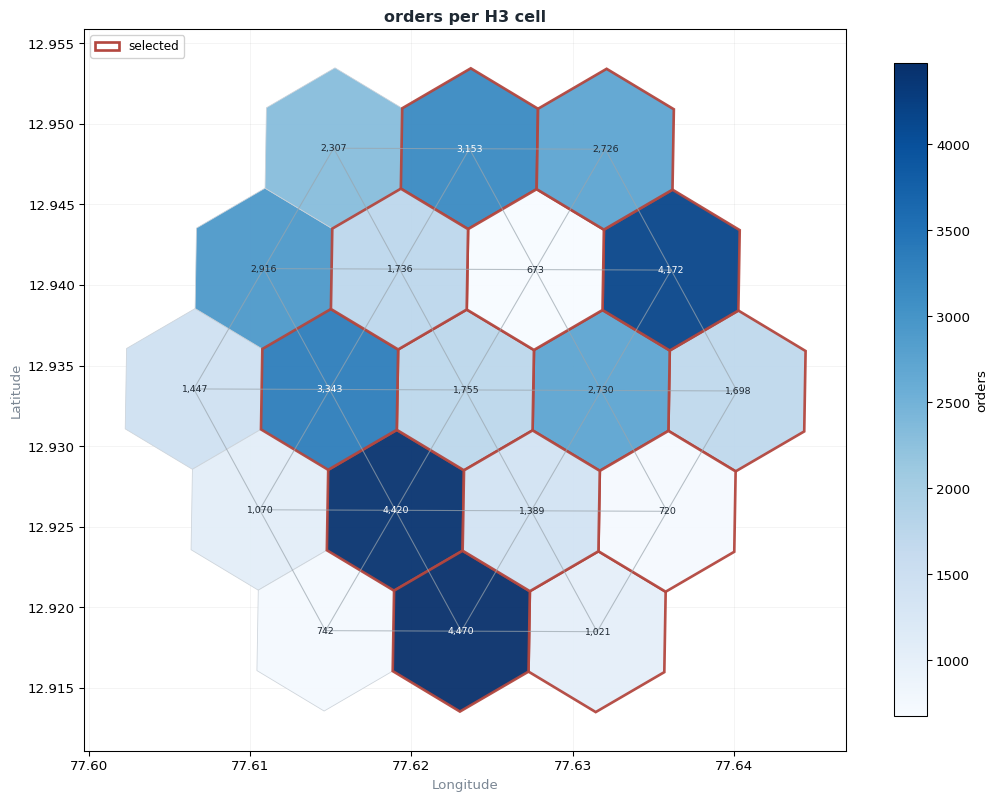

In [59]:
hg.plot_cells(metric='orders', highlight=corridor)